<a href="https://colab.research.google.com/github/Tiiso/ISM8X04-Assignment2/blob/main/Mental_Illness_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Learning From Data (ISM8X04)

# 220003917_Senosha

**Dataset:** Teen Mental Health Dataset
**Objective:** Apply machine learning models to classify depression labels based on teenager's digital and lifestyle habits.

In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

## 1. Data Source and Description
Loading the dataset to examine the features and the target variable (`depression_label`).

In [4]:
# Load Data
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# Display the first few rows to verify it loaded correctly
display(df.head())

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 2. Data Preprocessing
Here we separate our features (X) from our target (y), identify categorical vs. numeric columns, and build a preprocessing pipeline to handle missing values and scale/encode the data.

In [5]:
# Separate features and target
X = df.drop('depression_label', axis=1)
y = df['depression_label']

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute missing numbers with median
    ('scaler', StandardScaler())                   # Scale numbers
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute missing text with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encode categories
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (960, 12)
Testing data shape: (240, 12)


## 3. Machine Learning Models
We will train and evaluate three classification models:
1. Random Forest (RF)
2. Support Vector Machine (SVM)
3. Logistic Regression (LR)

In [6]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

results = {}

# Train and evaluate models
for name, model in models.items():
    # Create pipeline linking preprocessor to the model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])

    # Train the model
    clf.fit(X_train, y_train)

    # Make Predictions
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # Calculate and store metrics
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_prob)[0],
        'tpr': roc_curve(y_test, y_prob)[1],
        'roc_auc': auc(roc_curve(y_test, y_prob)[0], roc_curve(y_test, y_prob)[1])
    }

# Print tabular results
print(f"{'Model':<20} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 70)
for name, data in results.items():
    print(f"{name:<20} | {data['accuracy']:.4f}     | {data['precision']:.4f}     | {data['recall']:.4f}     | {data['f1']:.4f}")

Model                | Accuracy   | Precision  | Recall     | F1-Score  
----------------------------------------------------------------------
Random Forest        | 0.9750     | 0.0000     | 0.0000     | 0.0000
SVM                  | 0.9750     | 0.0000     | 0.0000     | 0.0000
Logistic Regression  | 0.9875     | 1.0000     | 0.5000     | 0.6667


## 4. Results Analysis (Visualizations)
Generating the Confusion Matrices and ROC Curves for the models.

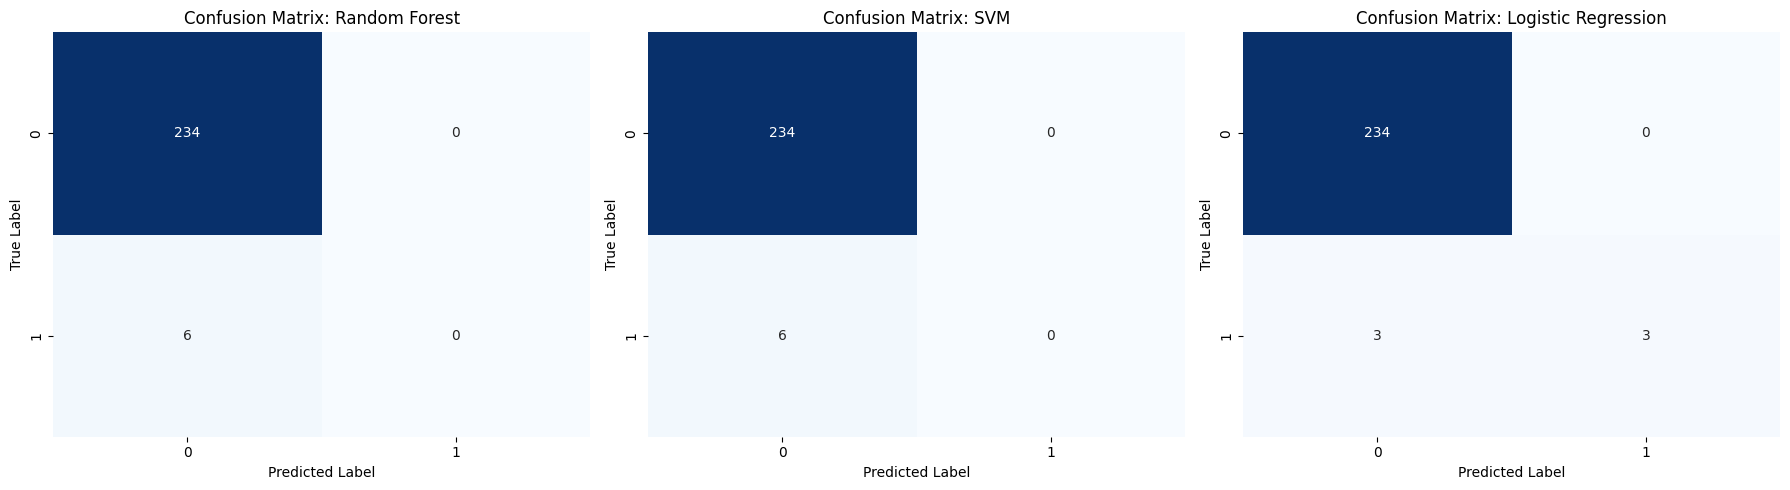

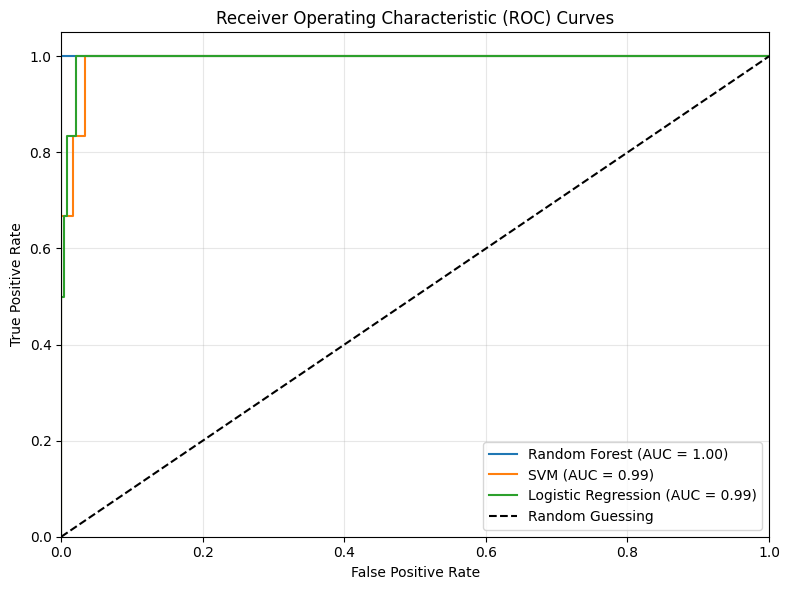

In [7]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, data) in zip(axes, results.items()):
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot ROC Curves
plt.figure(figsize=(8, 6))
for name, data in results.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['roc_auc']:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()